<a href="https://colab.research.google.com/github/riza93n-hub/data-science-2026/blob/main/Pertemuan9_RIZA_250401020014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aktivitas Hands On Pertemuan 9
**Nama Mahasiswa:** RIZA  
**NIM:** 250401020014  
**Kelas:** IF401

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# =====================================================================
# LANGKAH 1: LOAD & EDA SINGKAT
# =====================================================================
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0 = Malignant (Ganas), 1 = Benign (Jinak)

print('=== Eksplorasi Awal Data ===')
print('Shape Data (Baris, Kolom):', X.shape)
print('\nDistribusi Target (0: Ganas, 1: Jinak):')
print(pd.Series(y).value_counts(normalize=True).round(3))

# =====================================================================
# LANGKAH 2: PREPROCESSING (DATA SPLITTING & SCALING)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('\n✅ Preprocessing Selesai. Data siap dimasukkan ke dalam model.')

=== Eksplorasi Awal Data ===
Shape Data (Baris, Kolom): (569, 30)

Distribusi Target (0: Ganas, 1: Jinak):
1    0.627
0    0.373
Name: proportion, dtype: float64

✅ Preprocessing Selesai. Data siap dimasukkan ke dalam model.


In [2]:
from sklearn.linear_model import LogisticRegression

# =====================================================================
# LANGKAH 3: LATIH LOGISTIC REGRESSION
# =====================================================================
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
})

coef_df['Abs_Koefisien'] = coef_df['Koefisien'].abs()
coef_df = coef_df.sort_values('Abs_Koefisien', ascending=False).drop('Abs_Koefisien', axis=1)

print('=== 5 Fitur Paling Berpengaruh pada Logistic Regression ===')
print(coef_df.head().to_string(index=False))

=== 5 Fitur Paling Berpengaruh pada Logistic Regression ===
               Fitur  Koefisien
       worst texture  -1.255088
        radius error  -1.082965
worst concave points  -0.953686
          worst area  -0.947756
        worst radius  -0.947616


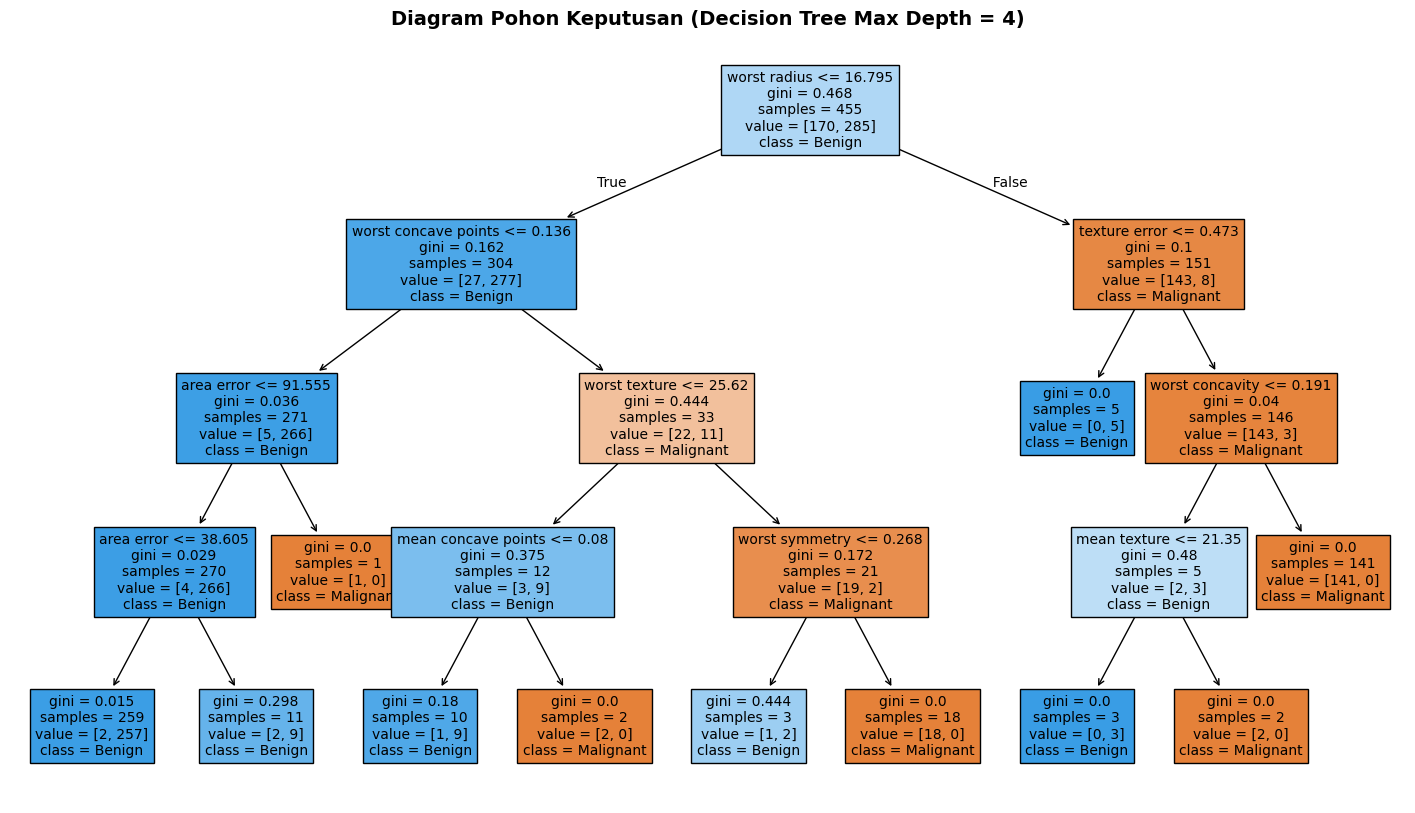

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# =====================================================================
# LANGKAH 4: LATIH DECISION TREE & VISUALISASI
# =====================================================================
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Malignant', 'Benign'],
    filled=True,
    fontsize=10
)
plt.title('Diagram Pohon Keputusan (Decision Tree Max Depth = 4)', fontsize=14, fontweight='bold')
plt.show()

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =====================================================================
# LANGKAH 5: EVALUASI & BANDINGKAN PERFORMA
# =====================================================================
print('=== HASIL PERBANDINGAN PERFORMA MODEL ===')

for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n▶ Model: {name}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f" - Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
    print(f" - Precision : {precision_score(y_test, y_pred):.3f}")
    print(f" - Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f" - F1-Score  : {f1_score(y_test, y_pred):.3f}")

=== HASIL PERBANDINGAN PERFORMA MODEL ===

▶ Model: Logistic Regression
Confusion Matrix:
[[41  1]
 [ 1 71]]
 - Accuracy  : 0.982
 - Precision : 0.986
 - Recall    : 0.986
 - F1-Score  : 0.986

▶ Model: Decision Tree
Confusion Matrix:
[[39  3]
 [ 4 68]]
 - Accuracy  : 0.939
 - Precision : 0.958
 - Recall    : 0.944
 - F1-Score  : 0.951


## Pembahasan Evaluasi Kasus Diagnosis Medis

1. **Model Terbaik (Recall):** **Logistic Regression** unggul dengan *Recall* **0.986** ($98.6\%$), dibandingkan *Decision Tree* yang hanya **0.944** ($94.4\%$).
2. **Urgensi Metrik Recall:** Dalam diagnosis kanker, kesalahan memprediksi pasien kanker sebagai jinak (*False Negative*) sangat berbahaya bagi keselamatan pasien. *Decision Tree* melewatkan **4 pasien** kanker, sedangkan *Logistic Regression* berhasil menekan kesalahan hingga hanya **1 pasien** yang terlewat. Oleh karena itu, *Recall* jauh lebih kritis daripada *Accuracy* semata.
3. **Interpretasi Fitur:**
   * **Logistic Regression (Akurasi 98.2%):** Fitur `worst texture` dan `radius error` memiliki koefisien negatif terbesar, artinya semakin tinggi nilainya, semakin kuat indikasi kanker ganas (Malignant).
   * **Decision Tree (Akurasi 93.9%):** Fitur `worst radius` menjadi akar penentu utama (root node). Jika `worst radius <= 16.795`, data cenderung diarahkan ke diagnosis jinak (Benign).

## Kesimpulan

* **Apa yang Dipelajari:** Membandingkan model *Logistic Regression* dan *Decision Tree* pada kasus klasifikasi medis, serta memahami pentingnya metrik evaluasi *Recall* dan visualisasi struktur pohon keputusan untuk transparansi model AI.
* **Temuan Utama:** *Logistic Regression* terbukti lebih optimal untuk dataset ini dengan akurasi $98.2\%$ dan *Recall* $98.6\%$. Melalui data, ditemukan bahwa karakteristik ukuran fisik luar sel (`worst radius`) dan tekstur sel (`worst texture`) merupakan indikator paling krusial dalam mendeteksi keganasan kanker.
* **Keterbatasan & Pertanyaan:**
  * *Keterbatasan:* Model *Decision Tree* ($max\_depth=4$) masih meloloskan 4 pasien kanker ganas sebagai pasien sehat (*False Negative*), tingkat risiko yang masih terlalu tinggi untuk standar medis nyata.
  * *Pertanyaan:* Bagaimana cara menaikkan nilai *Recall* hingga mencapai angka sempurna $100\%$ tanpa merusak performa akurasi umumnya secara ekstrem?